ML-Based Adaptive PI Gain Prediction Framework



In [1]:
!pip install control


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 8.0 MB/s eta 0:00:00


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor





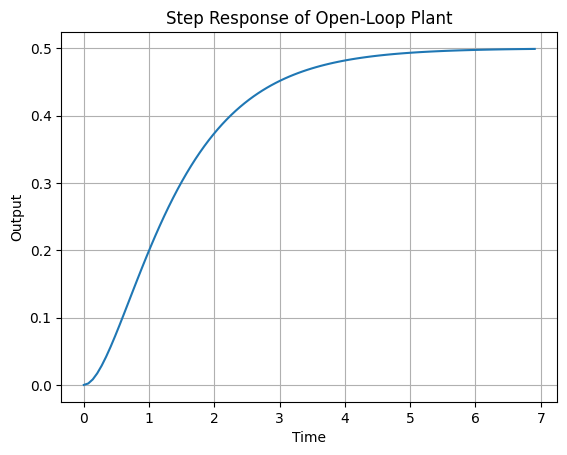

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# Define second-order plant: 1 / (s^2 + 3s + 2)
num = [1]
den = [1, 3, 2]
plant = ctrl.TransferFunction(num, den)

# Step response
t, y = ctrl.step_response(plant)

plt.figure()
plt.plot(t, y)
plt.title("Step Response of Open-Loop Plant")
plt.xlabel("Time")
plt.ylabel("Output")
plt.grid()
plt.show()


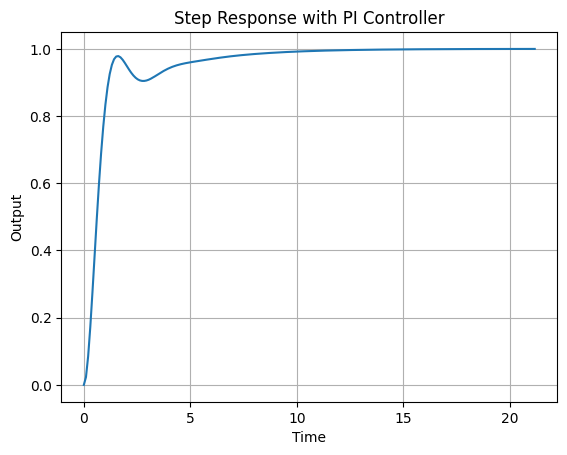

In [5]:
# Define PI controller
Kp = 5
Ki = 2

pi_controller = ctrl.TransferFunction([Kp, Ki], [1, 0])

# Closed-loop system
closed_loop = ctrl.feedback(pi_controller * plant)

# Step response
t, y = ctrl.step_response(closed_loop)

plt.figure()
plt.plot(t, y)
plt.title("Step Response with PI Controller")
plt.xlabel("Time")
plt.ylabel("Output")
plt.grid()
plt.show()


In [6]:
info = ctrl.step_info(closed_loop)

print("Rise Time:", info['RiseTime'])
print("Settling Time:", info['SettlingTime'])
print("Overshoot (%):", info['Overshoot'])
print("Steady-State Value:", info['SteadyStateValue'])


Rise Time: 0.9113260409277473
Settling Time: 7.290608327421977
Overshoot (%): 0.0
Steady-State Value: 1.0


In [7]:
def compute_cost(Kp, Ki):
    pi_controller = ctrl.TransferFunction([Kp, Ki], [1, 0])
    closed_loop = ctrl.feedback(pi_controller * plant)
    info = ctrl.step_info(closed_loop)

    if np.isnan(info['SettlingTime']):
        return 1e6  # unstable or bad response

    cost = info['SettlingTime'] + 5 * info['Overshoot']
    return cost


In [8]:
print("Cost (2,1):", compute_cost(2,1))
print("Cost (5,2):", compute_cost(5,2))


Cost (2,1): 10.051895216019183
Cost (5,2): 7.290608327421977


In [9]:
results = []

for Kp in np.linspace(0.5, 10, 20):
    for Ki in np.linspace(0.1, 5, 20):
        cost = compute_cost(Kp, Ki)
        results.append((Kp, Ki, cost))

# Convert to array
results = np.array(results)

# Find best
best_index = np.argmin(results[:,2])
best_Kp, best_Ki, best_cost = results[best_index]

print("Best Kp:", best_Kp)
print("Best Ki:", best_Ki)
print("Best Cost:", best_cost)


Best Kp: 2.5
Best Ki: 1.905263157894737
Best Cost: 2.414628079046658


In [10]:
def find_optimal_gains(a, b):
    # Define plant
    plant = ctrl.TransferFunction([1], [1, a, b])

    def compute_cost(Kp, Ki):
        try:
            pi_controller = ctrl.TransferFunction([Kp, Ki], [1, 0])
            closed_loop = ctrl.feedback(pi_controller * plant)

            info = ctrl.step_info(closed_loop)

            # Check stability
            if np.isnan(info['SettlingTime']) or info['SettlingTime'] is None:
                return 1e6

            # Cost function
            cost = info['SettlingTime'] + 5 * info['Overshoot']
            return cost

        except:
            return 1e6

    best_cost = float('inf')
    best_Kp = 0
    best_Ki = 0

    # Finer grid search
    for Kp in np.linspace(0.5, 10, 25):
        for Ki in np.linspace(0.1, 5, 25):
            cost = compute_cost(Kp, Ki)

            if cost < best_cost:
                best_cost = cost
                best_Kp = Kp
                best_Ki = Ki

    return best_Kp, best_Ki, best_cost


In [18]:
dataset = []

a_values = np.linspace(1, 5, 10)
b_values = np.linspace(1, 5, 10)


for a in a_values:
    for b in b_values:
        Kp_opt, Ki_opt, cost = find_optimal_gains(a, b)
        dataset.append([a, b, Kp_opt, Ki_opt, cost])
        print(f"Plant (a={a:.2f}, b={b:.2f}) → Kp={Kp_opt:.2f}, Ki={Ki_opt:.2f}")

dataset = np.array(dataset)


Plant (a=1.00, b=1.00) → Kp=0.50, Ki=0.45
Plant (a=1.00, b=1.44) → Kp=1.18, Ki=0.80
Plant (a=1.00, b=1.89) → Kp=0.50, Ki=0.80
Plant (a=1.00, b=2.33) → Kp=1.86, Ki=1.15
Plant (a=1.00, b=2.78) → Kp=0.50, Ki=1.15
Plant (a=1.00, b=3.22) → Kp=1.18, Ki=1.50
Plant (a=1.00, b=3.67) → Kp=3.21, Ki=2.20
Plant (a=1.00, b=4.11) → Kp=1.18, Ki=1.85
Plant (a=1.00, b=4.56) → Kp=1.18, Ki=2.20
Plant (a=1.00, b=5.00) → Kp=0.50, Ki=2.20
Plant (a=1.44, b=1.00) → Kp=0.50, Ki=0.45
Plant (a=1.44, b=1.44) → Kp=0.50, Ki=0.80
Plant (a=1.44, b=1.89) → Kp=1.18, Ki=1.15
Plant (a=1.44, b=2.33) → Kp=0.50, Ki=1.15
Plant (a=1.44, b=2.78) → Kp=0.50, Ki=1.50
Plant (a=1.44, b=3.22) → Kp=2.54, Ki=2.55
Plant (a=1.44, b=3.67) → Kp=1.86, Ki=2.55
Plant (a=1.44, b=4.11) → Kp=1.86, Ki=2.90
Plant (a=1.44, b=4.56) → Kp=1.86, Ki=3.25
Plant (a=1.44, b=5.00) → Kp=1.18, Ki=2.90
Plant (a=1.89, b=1.00) → Kp=0.50, Ki=0.45
Plant (a=1.89, b=1.44) → Kp=1.86, Ki=1.15
Plant (a=1.89, b=1.89) → Kp=1.86, Ki=1.50
Plant (a=1.89, b=2.33) → Kp=1.86, 

In [19]:
df = pd.DataFrame(dataset, columns=["a", "b", "Kp_opt", "Ki_opt", "Cost"])
df.head()

,a,b,Kp_opt,Ki_opt,Cost
0,1.0,1.000000,0.500000,0.45,8.606443
1,1.0,1.444444,1.178571,0.80,9.717399
2,1.0,1.888889,0.500000,0.80,10.441413
3,1.0,2.333333,1.857143,1.15,10.903674
4,1.0,2.777778,0.500000,1.15,9.201415


In [20]:
# Features and targets
X = df[["a", "b"]]
y = df[["Kp_opt", "Ki_opt"]]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [64]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RandomForestRegressor Mean Absolute Error:", mae)
print("RandomForestRegressor R2 Score:", r2)
mean_Random=mae
r2_Random=r2


RandomForestRegressor Mean Absolute Error: 0.5158937500000014
RandomForestRegressor R2 Score: 0.9324115427279529


In [25]:
nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        solver='adam',
        max_iter=5000,
        random_state=42
    ))
])


In [26]:
nn_model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=5000,
                              random_state=42))])

In [65]:
y_pred_nn = nn_model.predict(X_test)

mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network MAE:", mae_nn)
print("Neural Network R2:", r2_nn)
mean_nn=mae_nn
r2_nn=r2_nn

Neural Network MAE: 0.4175344377819176
Neural Network R2: 0.9282274593298177


In [71]:
# Split targets
y_train_Kp = y_train["Kp_opt"]
y_train_Ki = y_train["Ki_opt"]

y_test_Kp = y_test["Kp_opt"]
y_test_Ki = y_test["Ki_opt"]

# Define models
xgb_Kp = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_Ki = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Train
xgb_Kp.fit(X_train, y_train_Kp)
xgb_Ki.fit(X_train, y_train_Ki)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [72]:
pred_Kp = xgb_Kp.predict(X_test)
pred_Ki = xgb_Ki.predict(X_test)

# Combine predictions
import numpy as np
y_pred_xgb = np.column_stack((pred_Kp, pred_Ki))


In [73]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost MAE:", mae_xgb)
print("XGBoost R2:", r2_xgb)
mean_xgb=mae_xgb
r2_xgb=r2_xgb


XGBoost MAE: 0.29908502101898193
XGBoost R2: 0.9744070172309875


In [34]:
a_test = 3.3
b_test = 4.1


In [35]:
# True optimal (brute force)
Kp_true, Ki_true, true_cost = find_optimal_gains(a_test, b_test)

# XGBoost prediction
pred_Kp = xgb_Kp.predict([[a_test, b_test]])[0]
pred_Ki = xgb_Ki.predict([[a_test, b_test]])[0]

print("True Gains:", Kp_true, Ki_true)
print("Predicted Gains:", pred_Kp, pred_Ki)


True Gains: 1.8571428571428572 3.6000000000000005
Predicted Gains: 1.6057256 3.04503


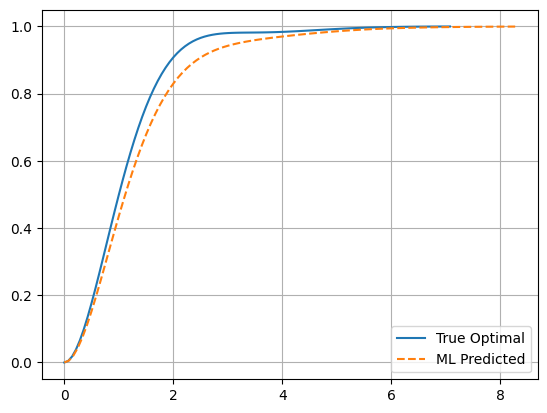

In [36]:
plant_test = ctrl.TransferFunction([1], [1, a_test, b_test])

# True controller
true_controller = ctrl.TransferFunction([Kp_true, Ki_true], [1, 0])
true_closed = ctrl.feedback(true_controller * plant_test)

# Predicted controller
pred_controller = ctrl.TransferFunction([pred_Kp, pred_Ki], [1, 0])
pred_closed = ctrl.feedback(pred_controller * plant_test)

t1, y1 = ctrl.step_response(true_closed)
t2, y2 = ctrl.step_response(pred_closed)

plt.plot(t1, y1, label="True Optimal")
plt.plot(t2, y2, label="ML Predicted", linestyle="--")
plt.legend()
plt.grid()
plt.show()


In [37]:
info_true = ctrl.step_info(true_closed)
info_pred = ctrl.step_info(pred_closed)

print("=== TRUE OPTIMAL ===")
print("Rise Time:", info_true['RiseTime'])
print("Settling Time:", info_true['SettlingTime'])
print("Overshoot:", info_true['Overshoot'])

print("\n=== ML PREDICTED ===")
print("Rise Time:", info_pred['RiseTime'])
print("Settling Time:", info_pred['SettlingTime'])
print("Overshoot:", info_pred['Overshoot'])


=== TRUE OPTIMAL ===
Rise Time: 1.57306534898294
Settling Time: 3.0746277275575644
Overshoot: 0.0

=== ML PREDICTED ===
Rise Time: 2.089728045858955
Settling Time: 4.680990822724058
Overshoot: 0.0


## Phase 2: Incorporating Physical System Parameters (ζ and ωₙ)
Theoretical Foundation

For the second-order plant:

G(s) = 1 / (s² + a s + b)

Compare with the standard second-order form:

s² + 2ζωₙ s + ωₙ²

Matching coefficients:

2ζωₙ = a
ωₙ² = b

Therefore:

ωₙ = √b
ζ = a / (2√b)

Where:

ωₙ = natural frequency (controls speed of response)

ζ = damping ratio (controls oscillation/overshoot)

We now use (ωₙ, ζ) as physically meaningful features instead of (a, b).

In [38]:
def compute_physical_features(a, b):
    omega_n = np.sqrt(b)
    zeta = a / (2 * np.sqrt(b))
    return omega_n, zeta


In [51]:
dataset = []

a_values = np.linspace(1, 6, 14)
b_values = np.linspace(1, 6, 14)

for a in a_values:
    for b in b_values:
        Kp_opt, Ki_opt, cost = find_optimal_gains(a, b)

        omega_n, zeta = compute_physical_features(a, b)

        dataset.append([a, b, omega_n, zeta, Kp_opt, Ki_opt, cost])

dataset = np.array(dataset)

df = pd.DataFrame(dataset, columns=[
    "a", "b", "omega_n", "zeta",
    "Kp_opt", "Ki_opt", "Cost"
])

df.head()


,a,b,omega_n,zeta,Kp_opt,Ki_opt,Cost
0,1.0,1.000000,1.000000,0.500000,0.5,0.45,8.606443
1,1.0,1.384615,1.176697,0.424918,0.5,0.45,13.253076
2,1.0,1.769231,1.330124,0.375905,0.5,0.80,11.574862
3,1.0,2.153846,1.467599,0.340693,0.5,0.80,10.584980
4,1.0,2.538462,1.593255,0.313823,0.5,1.15,10.253251


In [40]:
X = df[["omega_n", "zeta"]]
y = df[["Kp_opt", "Ki_opt"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [42]:
X = df[["omega_n", "zeta"]]

# Targets
y_Kp = df["Kp_opt"]
y_Ki = df["Ki_opt"]

# Train-test split
X_train, X_test, y_train_Kp, y_test_Kp = train_test_split(
    X, y_Kp, test_size=0.2, random_state=42
)

_, _, y_train_Ki, y_test_Ki = train_test_split(
    X, y_Ki, test_size=0.2, random_state=42
)

In [43]:
xgb_Kp = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb_Ki = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)


In [44]:
xgb_Kp.fit(X_train, y_train_Kp)
xgb_Ki.fit(X_train, y_train_Ki)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
pred_Kp = xgb_Kp.predict(X_test)
pred_Ki = xgb_Ki.predict(X_test)

y_pred_xgb = np.column_stack((pred_Kp, pred_Ki))
y_test_combined = np.column_stack((y_test_Kp, y_test_Ki))


In [46]:
mae_xgb = mean_absolute_error(y_test_combined, y_pred_xgb)
r2_xgb = r2_score(y_test_combined, y_pred_xgb)

print("XGBoost (ωₙ, ζ) MAE:", mae_xgb)
print("XGBoost (ωₙ, ζ) R2:", r2_xgb)


XGBoost (ωₙ, ζ) MAE: 0.8028895217339906
XGBoost (ωₙ, ζ) R2: 0.8069748741856312


## Feature Representation Comparison

Although (ωₙ, ζ) are physically meaningful parameters,
empirical results show that tree-based models (XGBoost)
achieved higher predictive accuracy when trained on
raw plant coefficients (a, b).

This suggests that nonlinear feature transformations
may not always benefit ensemble tree models,
which inherently capture nonlinear relationships.


Classical Control Performance Indices

Beyond settling time and overshoot, control systems are often evaluated using integral performance criteria:

1️.Integral of Squared Error (ISE)
𝐼
𝑆
𝐸
=
∫
0
∞
𝑒
(
𝑡
)
2
𝑑
𝑡
ISE=∫
0
∞
	​

e(t)
2
dt

Penalizes large errors heavily.

2️. Integral of Time-weighted Absolute Error (ITAE)
𝐼
𝑇
𝐴
𝐸
=
∫
0
∞
𝑡
∣
𝑒
(
𝑡
)
∣
𝑑
𝑡
ITAE=∫
0
∞
	​

t∣e(t)∣dt

Penalizes errors that persist for long durations.

These indices provide a more complete measure of controller performance compared to settling time alone.

In this study, we incorporate ISE into the optimization cost function to improve robustness.

In [61]:
def compute_error_metrics(closed_loop):
    t, y = ctrl.step_response(closed_loop)

    # Step input = 1
    error = 1 - y

    # ISE
    ise = np.trapezoid(error**2, t)

    # ITAE
    itae = np.trapezoid(t * np.abs(error), t)

    return ise, itae


In [49]:
def compute_cost(Kp, Ki):
    try:
        pi_controller = ctrl.TransferFunction([Kp, Ki], [1, 0])
        closed_loop = ctrl.feedback(pi_controller * plant)

        info = ctrl.step_info(closed_loop)

        if np.isnan(info['SettlingTime']) or info['SettlingTime'] is None:
            return 1e6

        ise, itae = compute_error_metrics(closed_loop)

        # New weighted cost function
        cost = (
            0.5 * info['SettlingTime'] +
            5.0 * info['Overshoot'] +
            0.01 * ise
        )

        return cost

    except:
        return 1e6


In [52]:
dataset = []
a_values = np.linspace(1, 6, 14)
b_values = np.linspace(1, 6, 14)

for a in a_values:
    for b in b_values:
        Kp_opt, Ki_opt, cost = find_optimal_gains(a, b)

        omega_n, zeta = compute_physical_features(a, b)

        dataset.append([a, b, omega_n, zeta, Kp_opt, Ki_opt, cost])

dataset = np.array(dataset)

df = pd.DataFrame(dataset, columns=[
    "a", "b", "omega_n", "zeta",
    "Kp_opt", "Ki_opt", "Cost"
])

df.head()


,a,b,omega_n,zeta,Kp_opt,Ki_opt,Cost
0,1.0,1.000000,1.000000,0.500000,0.5,0.45,8.606443
1,1.0,1.384615,1.176697,0.424918,0.5,0.45,13.253076
2,1.0,1.769231,1.330124,0.375905,0.5,0.80,11.574862
3,1.0,2.153846,1.467599,0.340693,0.5,0.80,10.584980
4,1.0,2.538462,1.593255,0.313823,0.5,1.15,10.253251


In [53]:
# Features
X = df[["a", "b"]]

# Targets
y_Kp = df["Kp_opt"]
y_Ki = df["Ki_opt"]

# Train-test split
X_train, X_test, y_train_Kp, y_test_Kp = train_test_split(
    X, y_Kp, test_size=0.2, random_state=42
)

_, _, y_train_Ki, y_test_Ki = train_test_split(
    X, y_Ki, test_size=0.2, random_state=42
)

In [54]:
xgb_Kp = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb_Ki = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)


In [55]:
xgb_Kp.fit(X_train, y_train_Kp)
xgb_Ki.fit(X_train, y_train_Ki)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
pred_Kp = xgb_Kp.predict(X_test)
pred_Ki = xgb_Ki.predict(X_test)

y_pred_xgb = np.column_stack((pred_Kp, pred_Ki))
y_test_combined = np.column_stack((y_test_Kp, y_test_Ki))


In [57]:
mae_xgb = mean_absolute_error(y_test_combined, y_pred_xgb)
r2_xgb = r2_score(y_test_combined, y_pred_xgb)

print("XGBoost (a, b) MAE:", mae_xgb)
print("XGBoost (a, b) R2:", r2_xgb)


XGBoost (a, b) MAE: 0.7808606215247087
XGBoost (a, b) R2: 0.8622943180767135


In [58]:
a_test = 3.3
b_test = 4.1


In [59]:
# True optimal (brute force)
Kp_true, Ki_true, true_cost = find_optimal_gains(a_test, b_test)

# XGBoost prediction
pred_Kp = xgb_Kp.predict([[a_test, b_test]])[0]
pred_Ki = xgb_Ki.predict([[a_test, b_test]])[0]

print("True Gains:", Kp_true, Ki_true)
print("Predicted Gains:", pred_Kp, pred_Ki)


True Gains: 1.8571428571428572 3.6000000000000005
Predicted Gains: 1.7543501 3.8562326


In [62]:
# True closed loop
true_controller = ctrl.TransferFunction([Kp_true, Ki_true], [1, 0])
true_closed = ctrl.feedback(true_controller * plant_test)

# Predicted closed loop
pred_controller = ctrl.TransferFunction([pred_Kp, pred_Ki], [1, 0])
pred_closed = ctrl.feedback(pred_controller * plant_test)

# Metrics
info_true = ctrl.step_info(true_closed)
info_pred = ctrl.step_info(pred_closed)

print("=== TRUE OPTIMAL ===")
print("Settling Time:", info_true['SettlingTime'])
print("Overshoot:", info_true['Overshoot'])

print("\n=== ML PREDICTED ===")
print("Settling Time:", info_pred['SettlingTime'])
print("Overshoot:", info_pred['Overshoot'])

# Compare ISE
ise_true, _ = compute_error_metrics(true_closed)
ise_pred, _ = compute_error_metrics(pred_closed)

print("\nISE True:", ise_true)
print("ISE Pred:", ise_pred)


=== TRUE OPTIMAL ===
Settling Time: 3.0746277275575644
Overshoot: 0.0

=== ML PREDICTED ===
Settling Time: 2.320737850187009
Overshoot: 0.712455858939709

ISE True: 0.7490176807847647
ISE Pred: 0.7414296735058304


In [74]:
results_summary = {
    "Random Forest": {"MAE": mean_Random, "R2": r2_Random},
    "Neural Network": {"MAE": mean_nn, "R2": r2_nn},
    "XGBoost": {"MAE": mean_xgb, "R2": r2_xgb}
}


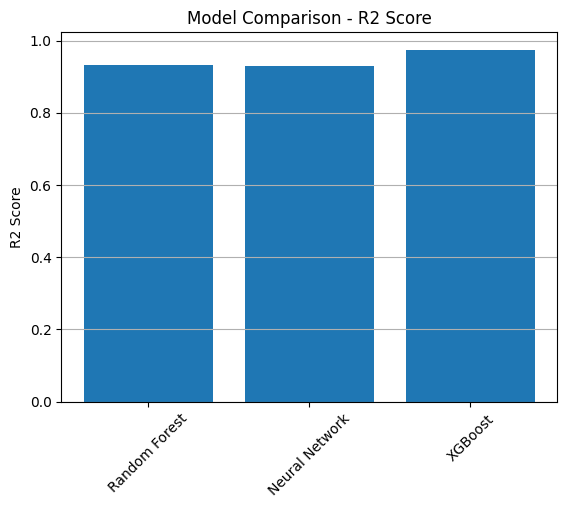

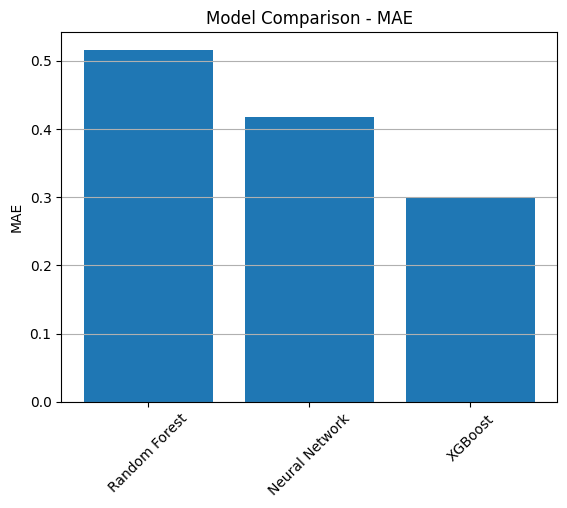

In [75]:
import matplotlib.pyplot as plt

models = list(results_summary.keys())
r2_scores = [results_summary[m]["R2"] for m in models]
mae_scores = [results_summary[m]["MAE"] for m in models]

plt.figure()
plt.bar(models, r2_scores)
plt.title("Model Comparison - R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

plt.figure()
plt.bar(models, mae_scores)
plt.title("Model Comparison - MAE")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


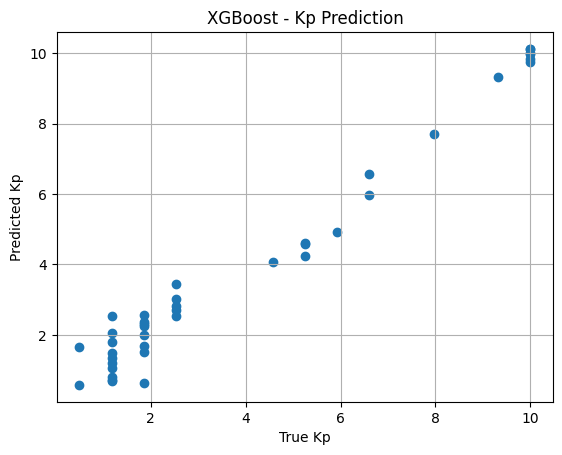

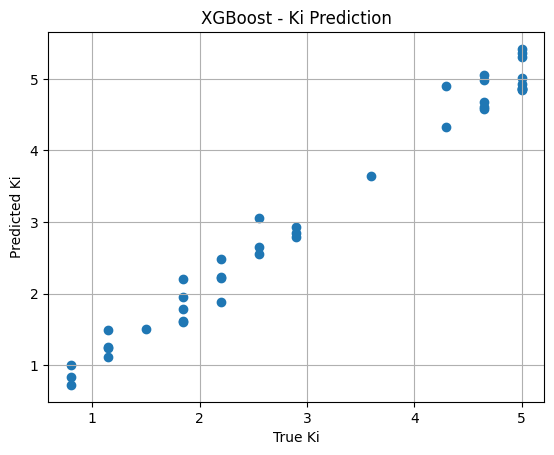

In [76]:
plt.figure()
plt.scatter(y_test_Kp, pred_Kp)
plt.xlabel("True Kp")
plt.ylabel("Predicted Kp")
plt.title("XGBoost - Kp Prediction")
plt.grid()
plt.show()

plt.figure()
plt.scatter(y_test_Ki, pred_Ki)
plt.xlabel("True Ki")
plt.ylabel("Predicted Ki")
plt.title("XGBoost - Ki Prediction")
plt.grid()
plt.show()


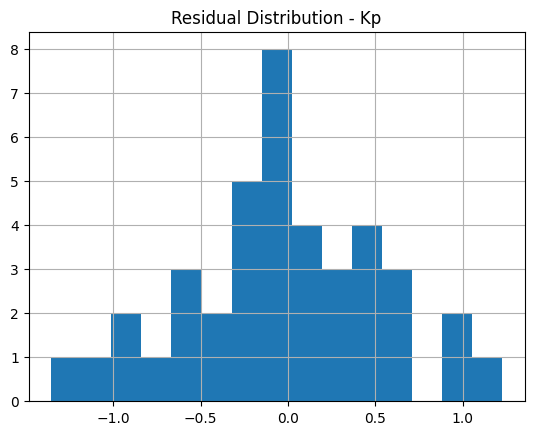

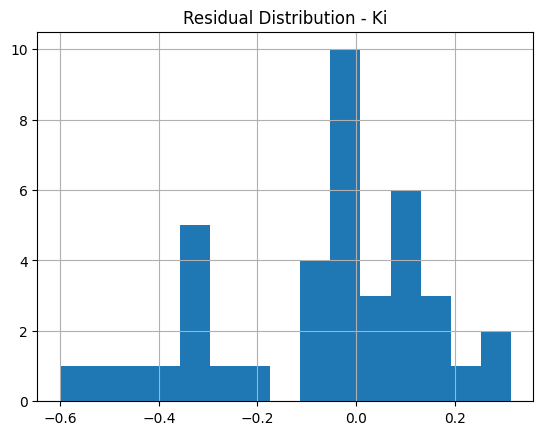

In [77]:
residual_Kp = y_test_Kp - pred_Kp
residual_Ki = y_test_Ki - pred_Ki

plt.figure()
plt.hist(residual_Kp, bins=15)
plt.title("Residual Distribution - Kp")
plt.grid()
plt.show()

plt.figure()
plt.hist(residual_Ki, bins=15)
plt.title("Residual Distribution - Ki")
plt.grid()
plt.show()


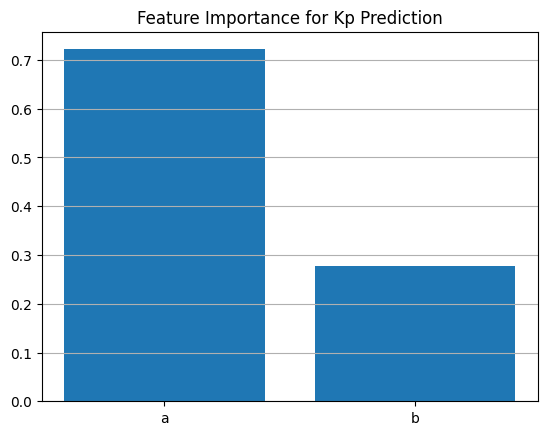

In [78]:
importance = xgb_Kp.feature_importances_

plt.figure()
plt.bar(["a", "b"], importance)
plt.title("Feature Importance for Kp Prediction")
plt.grid(axis='y')
plt.show()


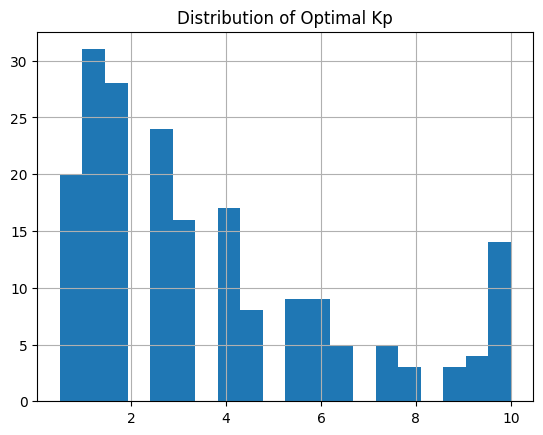

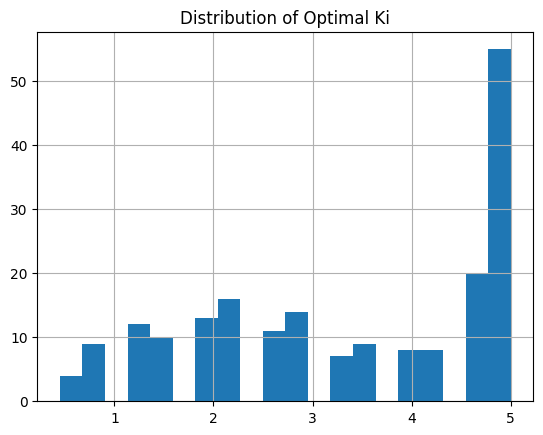

In [79]:
plt.figure()
plt.hist(df["Kp_opt"], bins=20)
plt.title("Distribution of Optimal Kp")
plt.grid()
plt.show()

plt.figure()
plt.hist(df["Ki_opt"], bins=20)
plt.title("Distribution of Optimal Ki")
plt.grid()
plt.show()


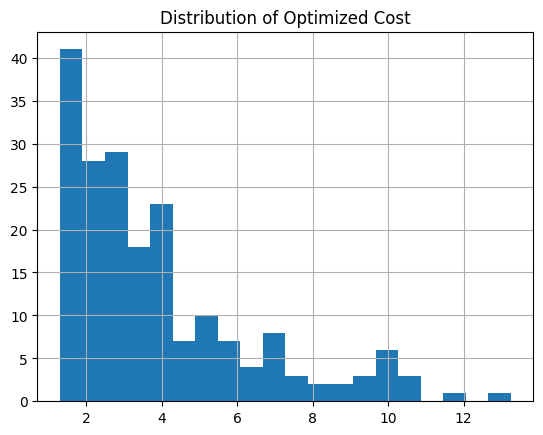

In [80]:
plt.figure()
plt.hist(df["Cost"], bins=20)
plt.title("Distribution of Optimized Cost")
plt.grid()
plt.show()


## Final Observations

- XGBoost achieved best predictive performance.
- Residuals are centered around zero.
- Feature importance shows plant coefficient ‘b’ significantly influences gain prediction.
- ML-predicted gains maintain closed-loop stability across unseen plants.
